# ¿Existe un mejor mes para contratar una hipoteca en España?

**Análisis histórico, estacionalidad y previsión del tipo hipotecario**

Autor: Jorge Bautista García

## 1. Objetivo

Este análisis nació como soporte de datos y gráficos para
[calculatucuota.es](https://calculatucuota.es), una web de simulación de
hipotecas, con el fin de hacer seguimiento del mercado hipotecario español:
evolución de los tipos, relación con el Euríbor, posible estacionalidad
mensual y previsión a corto plazo.

No es un trabajo de econometría causal. El objetivo es un análisis financiero
aplicado: comprobar qué dice realmente el dato, con un nivel de rigor
suficiente para no sacar conclusiones falsas, sin convertirlo en un tratado
académico.

Las preguntas que guían el análisis:

- ¿Existe un mes del año en el que sea sistemáticamente más barato contratar
  una hipoteca?
- ¿Cómo se relacionan el tipo hipotecario medio y el Euríbor a 12 meses?
- ¿Se comportan igual las hipotecas a tipo fijo y a tipo variable?
- ¿Qué evolución cabe esperar a 1, 3 y 6 meses, y qué modelo de previsión
  funciona mejor en validación histórica?

## 2. Fuentes de datos

- **INE**, tabla [24457](https://www.ine.es/jaxiT3/files/t/csv_bdsc/24457.csv):
  tipo de interés medio al inicio de las hipotecas constituidas sobre
  fincas, por naturaleza de la finca y tipo de interés (fijo/variable/total).
- **Banco de España**, catálogo de tipos de interés mensuales: serie
  `D_1NBAF472` (Euríbor a 12 meses).

Ambas series se descargan directamente desde sus URLs oficiales con
`src/download_data.py` y se validan con `src/validate_data.py`. El detalle de
columnas y controles de calidad está en `DATA_SOURCES.md`.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SRC_DIR))

import data_processing as dp
import analysis as an
import forecasting as fc

COLOR_TOTAL = "#111111"
COLOR_FIJO = "#B26A00"
COLOR_VARIABLE = "#16697A"
COLOR_EURIBOR = "#6A737D"
COLOR_MAIN = "#16697A"
COLOR_ACCENT = "#B26A00"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


def save_fig(fig, name):
    fig.savefig(FIGURES_DIR / name, dpi=150, bbox_inches="tight")

## 3. Carga y preparación de datos

In [2]:
dp.check_data_quality()

hipotecas, euribor = dp.load_raw_tables()
viviendas = dp.mortgage_series(hipotecas)
mortgage = viviendas[["fecha", "tipo_hipotecario"]]

cobertura = pd.DataFrame([
    {
        "Serie": "Tipo hipotecario de viviendas",
        "Inicio": viviendas["fecha"].min().date(),
        "Fin": viviendas["fecha"].max().date(),
        "Observaciones": len(viviendas),
    },
    {
        "Serie": "Euríbor a 12 meses",
        "Inicio": euribor["fecha"].min().date(),
        "Fin": euribor["fecha"].max().date(),
        "Observaciones": len(euribor),
    },
])
cobertura

,Serie,Inicio,Fin,Observaciones
0,Tipo hipotecario de viviendas,2009-01-01,2026-06-01,210
1,Euríbor a 12 meses,1999-01-01,2026-08-01,332


El análisis usa tipos medios de las hipotecas constituidas sobre viviendas
(no precios ofertados por bancos). Los datos no se modifican de forma
silenciosa: `data/raw/` conserva la descarga original y `data/processed/`
contiene las tablas ya limpias que usa el resto del cuaderno.

## 4. Evolución histórica de los tipos hipotecarios

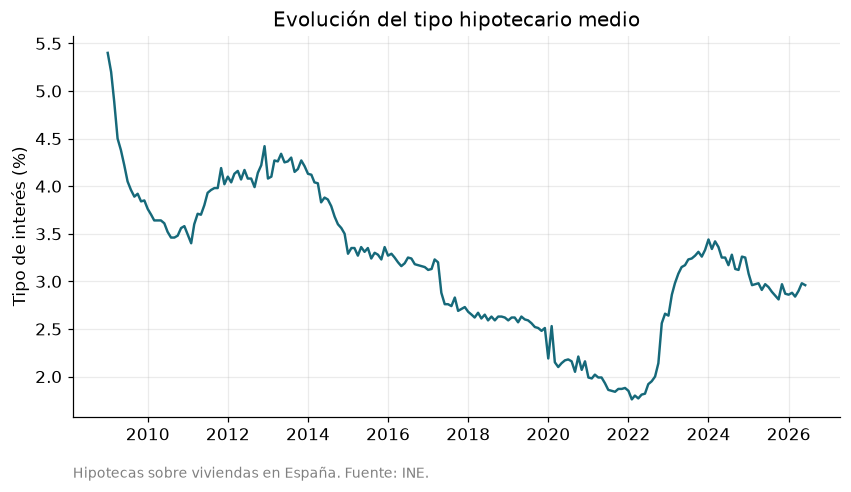

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(viviendas["fecha"], viviendas["tipo_hipotecario"], color=COLOR_MAIN, linewidth=1.6)
ax.set_title("Evolución del tipo hipotecario medio")
ax.set_ylabel("Tipo de interés (%)")
ax.set_xlabel(None)
fig.suptitle("")
ax.text(0.0, -0.16, "Hipotecas sobre viviendas en España. Fuente: INE.", transform=ax.transAxes,
        fontsize=9, color="grey")
save_fig(fig, "01_evolucion_tipo_hipotecario.png")
plt.show()

Para no elegir a simple vista las distintas etapas del mercado, buscamos
fechas en las que la trayectoria del Euríbor cambia lo suficiente como para
separar el periodo anterior del siguiente (**rupturas**). No significa que el
mercado se detuviera, sino que empezó una etapa con un comportamiento
distinto. Usamos una partición óptima por mínimos cuadrados: para cada
número de rupturas se busca la partición que minimiza la suma de cuadrados
de los residuos, y se elige el número de rupturas que minimiza el BIC.

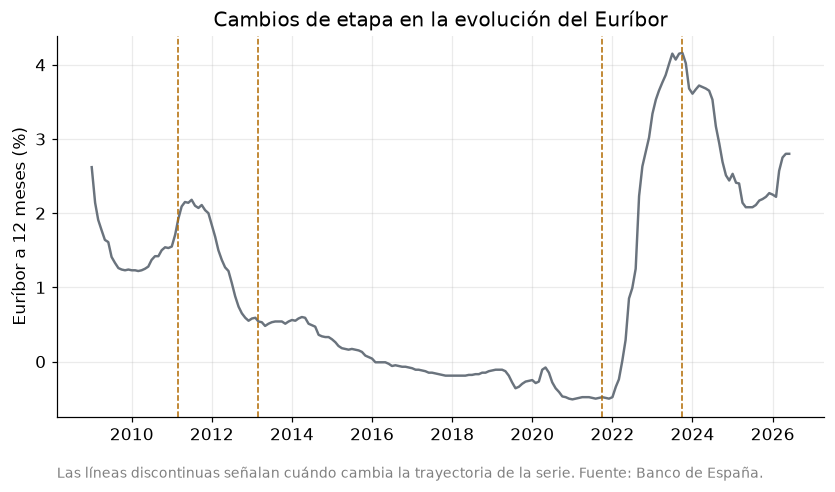

,Etapa,Inicio,Fin,euribor_12m_inicial,euribor_12m_final,Cambio
0,1,2009-01-01,2011-02-01,2.62,1.71,-0.91
1,2,2011-03-01,2013-02-01,1.92,0.59,-1.33
2,3,2013-03-01,2021-09-01,0.54,-0.49,-1.03
3,4,2021-10-01,2023-09-01,-0.48,4.15,4.63
4,5,2023-10-01,2026-06-01,4.16,2.80,-1.36


In [4]:
inicio_comun = max(viviendas["fecha"].min(), euribor["fecha"].min())
fin_comun = min(viviendas["fecha"].max(), euribor["fecha"].max())
euribor_regimenes = euribor[(euribor["fecha"] >= inicio_comun) & (euribor["fecha"] <= fin_comun)].reset_index(drop=True)

break_idx, etapas = an.detect_breakpoints(euribor_regimenes, "euribor_12m", max_breaks=5, min_segment_length=24)
fechas_ruptura = euribor_regimenes["fecha"].iloc[break_idx]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(euribor_regimenes["fecha"], euribor_regimenes["euribor_12m"], color=COLOR_EURIBOR, linewidth=1.6)
for f in fechas_ruptura:
    ax.axvline(f, color=COLOR_ACCENT, linestyle="--", linewidth=1)
ax.set_title("Cambios de etapa en la evolución del Euríbor")
ax.set_ylabel("Euríbor a 12 meses (%)")
ax.text(0.0, -0.16, "Las líneas discontinuas señalan cuándo cambia la trayectoria de la serie. Fuente: Banco de España.",
        transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "02_rupturas_euribor.png")
plt.show()

etapas

Superponemos las tres series (tipo medio, fijo, variable) junto al Euríbor
para ver cómo se mueven entre sí a lo largo de esas etapas.

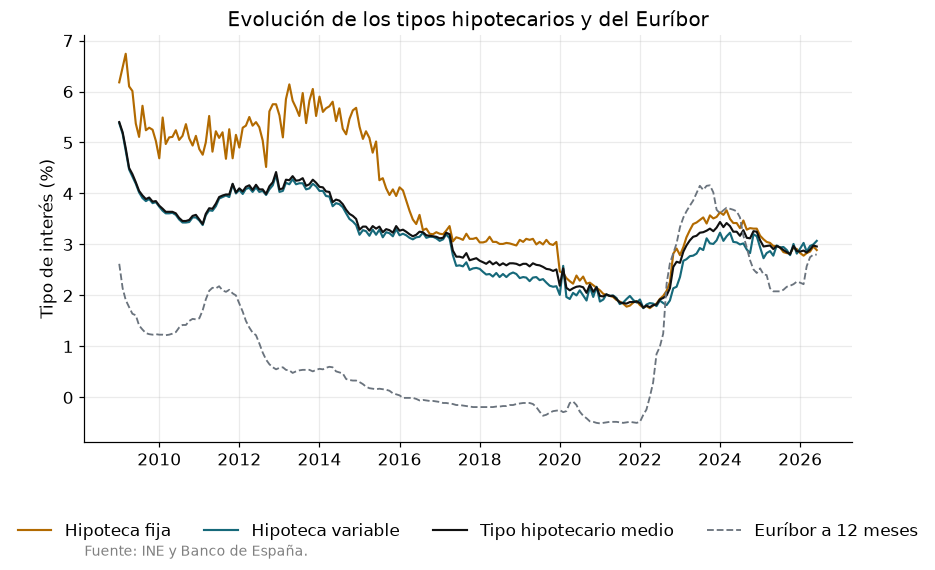

In [5]:
historico = hipotecas[hipotecas["naturaleza_finca"] == "Viviendas"][["fecha", "tipo_interes", "tipo_hipotecario"]].copy()
historico["serie"] = historico["tipo_interes"].map({
    "Total": "Tipo hipotecario medio", "Fijo": "Hipoteca fija", "Variable": "Hipoteca variable"
})
historico = historico[(historico["fecha"] >= inicio_comun) & (historico["fecha"] <= fin_comun)]

fig, ax = plt.subplots(figsize=(9, 4.8))
colores = {"Tipo hipotecario medio": COLOR_TOTAL, "Hipoteca fija": COLOR_FIJO, "Hipoteca variable": COLOR_VARIABLE}
for serie, grupo in historico.groupby("serie"):
    ax.plot(grupo["fecha"], grupo["tipo_hipotecario"], label=serie, color=colores[serie], linewidth=1.4)
euribor_comun = euribor[(euribor["fecha"] >= inicio_comun) & (euribor["fecha"] <= fin_comun)]
ax.plot(euribor_comun["fecha"], euribor_comun["euribor_12m"], label="Euríbor a 12 meses", color=COLOR_EURIBOR, linewidth=1.2, linestyle="--")
ax.set_title("Evolución de los tipos hipotecarios y del Euríbor")
ax.set_ylabel("Tipo de interés (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, frameon=False)
ax.text(0.0, -0.28, "Fuente: INE y Banco de España.", transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "03_historico_tipos_euribor.png")
plt.show()

Las rupturas dividen la serie en varias etapas con comportamientos muy
distintos: caídas prolongadas del Euríbor hasta tipos negativos, y una subida
muy rápida en 2022-2023. El tipo hipotecario medio se mueve en la misma
dirección general, pero, como veremos en la siguiente sección, no siempre al
mismo ritmo ni con la misma intensidad.

## 5. Euríbor y tipos hipotecarios

¿Se traslada un cambio del Euríbor al tipo hipotecario medio dentro del mismo
mes? Comparamos los cambios mensuales de ambas series **dentro de cada
etapa**, para no concluir que existe una relación solo porque las dos series
subieron o bajaron durante varios años seguidos.

- La **correlación** indica si ambas series suelen moverse en la misma
  dirección (cerca de 1: relación fuerte; cerca de 0: sin relación clara).
- La **sensibilidad** estima cuánto cambia el tipo hipotecario cuando el
  Euríbor varía un punto porcentual. Es una comparación descriptiva, no
  identifica una relación causal.

In [6]:
hipoteca_total = hipotecas[(hipotecas["naturaleza_finca"] == "Viviendas") & (hipotecas["tipo_interes"] == "Total")][["fecha", "tipo_hipotecario"]]
resumen_relacion = an.stage_relationship(hipoteca_total, euribor, etapas)
resumen_relacion

,etapa,Observaciones,Correlacion,Sensibilidad
0,1,25.0,0.60,0.50
1,2,23.0,0.05,0.07
2,3,102.0,-0.14,-0.37
3,4,23.0,0.06,0.03
4,5,32.0,-0.16,-0.09


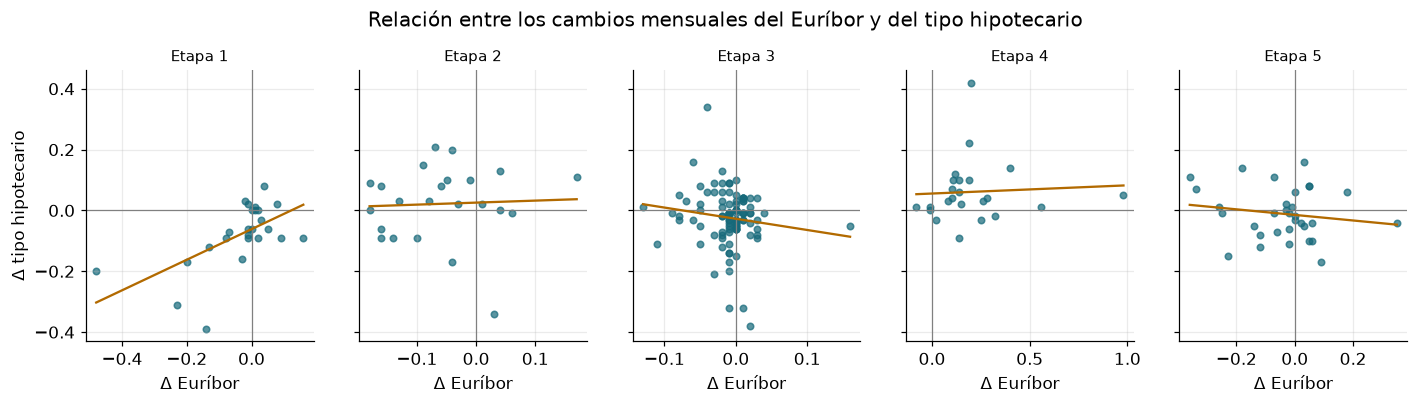

In [7]:
datos_relacion = hipoteca_total.merge(euribor[["fecha", "euribor_12m"]], on="fecha", how="inner").sort_values("fecha")
datos_relacion["etapa"] = an.assign_stage(datos_relacion["fecha"], etapas)
datos_relacion["cambio_hipoteca"] = datos_relacion.groupby("etapa")["tipo_hipotecario"].diff()
datos_relacion["cambio_euribor"] = datos_relacion.groupby("etapa")["euribor_12m"].diff()
datos_relacion = datos_relacion.dropna(subset=["cambio_hipoteca", "cambio_euribor"])

n_etapas = datos_relacion["etapa"].nunique()
fig, axes = plt.subplots(1, n_etapas, figsize=(3.1 * n_etapas, 3.2), sharey=True)
for ax, (etapa, grupo) in zip(axes, datos_relacion.groupby("etapa")):
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.scatter(grupo["cambio_euribor"], grupo["cambio_hipoteca"], color=COLOR_MAIN, alpha=0.7, s=18)
    if len(grupo) > 1 and grupo["cambio_euribor"].std() > 0:
        coef = np.polyfit(grupo["cambio_euribor"], grupo["cambio_hipoteca"], 1)
        xs = np.linspace(grupo["cambio_euribor"].min(), grupo["cambio_euribor"].max(), 20)
        ax.plot(xs, np.polyval(coef, xs), color=COLOR_ACCENT, linewidth=1.5)
    ax.set_title(f"Etapa {etapa}", fontsize=10)
    ax.set_xlabel("Δ Euríbor")
axes[0].set_ylabel("Δ tipo hipotecario")
fig.suptitle("Relación entre los cambios mensuales del Euríbor y del tipo hipotecario", y=1.05)
save_fig(fig, "04_relacion_euribor_hipoteca_por_etapa.png")
plt.show()

La relación mensual más intensa aparece en la primera etapa, cuando el
Euríbor todavía se movía en un rango amplio y positivo. En las etapas
siguientes la relación se debilita e incluso cambia de signo: esto no
significa que el Euríbor no influya en las hipotecas (a largo plazo,
claramente sí, como muestra la sección anterior), sino que sus variaciones
mes a mes no se trasladan de forma automática y regular al tipo medio en el
mismo mes: hay retrasos, cambios en la mezcla de operaciones fijas/variables
y otros factores del mercado.

## 6. Estacionalidad

**¿Existe un mes del año en el que sea sistemáticamente más barato contratar
una hipoteca?**

Primero comparamos cada mes con la media de su propio año, para que los años
con tipos muy altos o muy bajos no distorsionen la comparación.

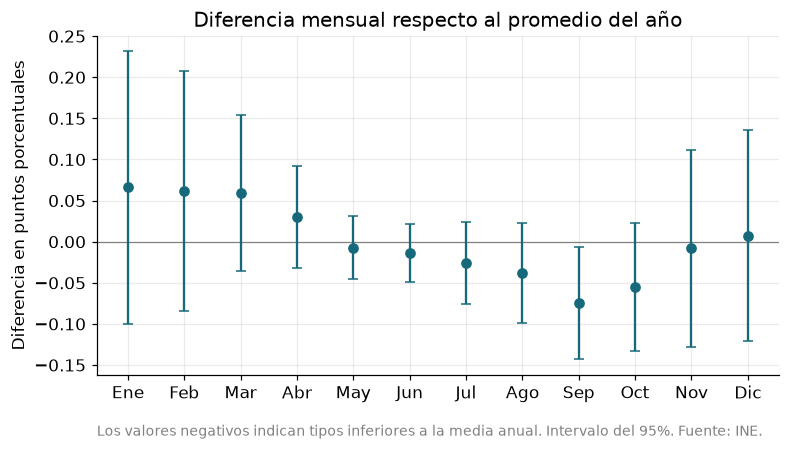

Mes con la diferencia media más baja: Sep


In [8]:
patron_mensual = an.monthly_deviation_from_annual_mean(viviendas)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="grey", linewidth=0.8)
ax.errorbar(
    patron_mensual["mes"], patron_mensual["diferencia_media"],
    yerr=[patron_mensual["diferencia_media"] - patron_mensual["inferior"],
          patron_mensual["superior"] - patron_mensual["diferencia_media"]],
    fmt="o", color=COLOR_MAIN, ecolor=COLOR_MAIN, capsize=3,
)
ax.set_title("Diferencia mensual respecto al promedio del año")
ax.set_ylabel("Diferencia en puntos porcentuales")
ax.text(0.0, -0.18, "Los valores negativos indican tipos inferiores a la media anual. Intervalo del 95%. Fuente: INE.",
        transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "05_diferencia_mensual_media_anual.png")
plt.show()

mes_minimo = patron_mensual.loc[patron_mensual["diferencia_media"].idxmin(), "mes"]
print(f"Mes con la diferencia media más baja: {mes_minimo}")

Esta primera comparación es puramente descriptiva: no controla por el nivel
del Euríbor, que cambia mucho de una década a otra y puede generar
diferencias mensuales aparentes solo por la composición de años que caen en
cada periodo de tipos altos o bajos. Para comprobarlo con más cuidado,
ajustamos un modelo que controla por el nivel del Euríbor de los últimos
siete meses (para capturar el traslado con retraso que vimos en la sección
anterior) y por una tendencia temporal, y comparamos un modelo con variables
de mes frente a uno sin ellas. Como los datos mensuales suelen estar
autocorrelados, los errores del modelo se ajustan con una estructura AR(2)
(mínimos cuadrados generalizados iterativos).

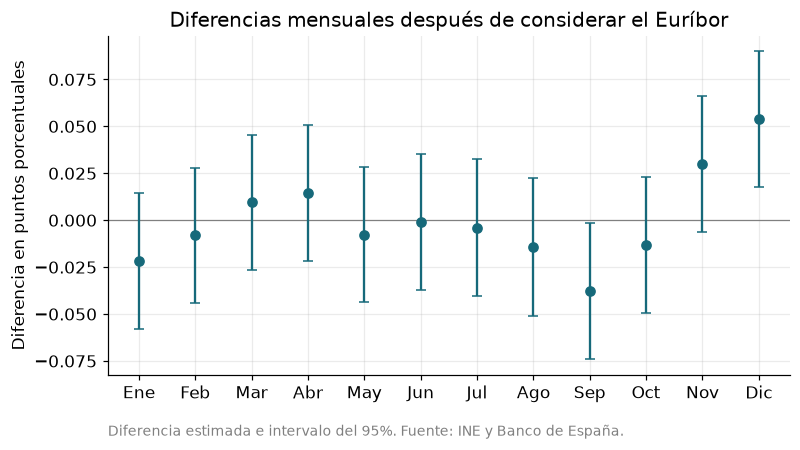

Prueba conjunta de las diferencias mensuales: p = 0.018
Comprobación de los residuos (Ljung-Box, 24 retardos): p = 0.064


In [9]:
tabla_meses_efecto, p_global, p_ljung_box, n_modelo = an.glsar_month_effect_test(mortgage, euribor)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="grey", linewidth=0.8)
ax.errorbar(
    tabla_meses_efecto["mes"], tabla_meses_efecto["efecto"],
    yerr=1.96 * tabla_meses_efecto["error"], fmt="o", color=COLOR_MAIN, ecolor=COLOR_MAIN, capsize=3,
)
ax.set_title("Diferencias mensuales después de considerar el Euríbor")
ax.set_ylabel("Diferencia en puntos porcentuales")
ax.text(0.0, -0.18, "Diferencia estimada e intervalo del 95%. Fuente: INE y Banco de España.",
        transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "06_diferencia_mensual_ajustada_euribor.png")
plt.show()

print(f"Prueba conjunta de las diferencias mensuales: p = {p_global:.3f}")
print(f"Comprobación de los residuos (Ljung-Box, 24 retardos): p = {p_ljung_box:.3f}")

La prueba conjunta indica que, en el conjunto de los datos históricos, las
diferencias entre meses no son puramente ruido. Pero antes de interpretar
cualquier mes en particular, hay que corregir por el hecho de estar
comparando doce meses a la vez (más comparaciones, más probabilidad de que
alguna parezca significativa por azar). Aplicamos la corrección de Holm.

In [10]:
tabla_holm = an.holm_corrected_month_table(tabla_meses_efecto)
tabla_holm_mostrar = tabla_holm[["mes", "efecto", "p_ajustado", "resultado"]].round(3)
tabla_holm_mostrar.columns = ["Mes", "Diferencia estimada", "p-valor ajustado", "Resultado"]
tabla_holm_mostrar

,Mes,Diferencia estimada,p-valor ajustado,Resultado
0,Ene,-0.022,1.000,Sin diferencia fiable
1,Feb,-0.008,1.000,Sin diferencia fiable
2,Mar,0.009,1.000,Sin diferencia fiable
3,Abr,0.014,1.000,Sin diferencia fiable
4,May,-0.008,1.000,Sin diferencia fiable
5,Jun,-0.001,1.000,Sin diferencia fiable
6,Jul,-0.004,1.000,Sin diferencia fiable
7,Ago,-0.014,1.000,Sin diferencia fiable
8,Sep,-0.038,0.453,Sin diferencia fiable
9,Oct,-0.013,1.000,Sin diferencia fiable


In [11]:
meses_inferiores = tabla_holm.loc[tabla_holm["resultado"] == "Tipo inferior", "mes"].tolist()
meses_superiores = tabla_holm.loc[tabla_holm["resultado"] == "Tipo superior", "mes"].tolist()
if meses_inferiores:
    print("Meses con un tipo estadísticamente inferior:", ", ".join(meses_inferiores))
else:
    print("Ningún mes presenta una reducción estadísticamente fiable tras corregir las doce comparaciones.")
if meses_superiores:
    print("Meses con un tipo estadísticamente superior:", ", ".join(meses_superiores))

Ningún mes presenta una reducción estadísticamente fiable tras corregir las doce comparaciones.
Meses con un tipo estadísticamente superior: Dic


La conclusión importante no es la lista de p-valores, sino esta: **ningún mes
ofrece de forma fiable un tipo más bajo**. La única diferencia que sobrevive
a la corrección por comparaciones múltiples es que diciembre tiende a un tipo
algo más alto, no más bajo — lo contrario de lo que buscaría alguien que
quisiera "esperar al mejor mes". Antes de darlo por definitivo, las dos
secciones siguientes comprueban si este patrón es estable en el tiempo y si
se repite igual en hipotecas fijas y variables.

## 7. Hipotecas fijas y variables

El tipo hipotecario medio combina operaciones a tipo fijo y variable, que
pueden comportarse de forma distinta. Repetimos el contraste de estacionalidad
por separado para cada producto.

In [12]:
resultados_tipos = an.fixed_vs_variable_test(hipotecas, euribor)
resultados_tipos

,Tipo,p_valor,Diferencias mensuales
0,Total,0.018,Sí
1,Fijo,0.039,Sí
2,Variable,0.584,No


Las hipotecas fijas y variables no muestran el mismo resultado: esa falta de
estabilidad entre productos es otro indicio de que no existe un mes
generalmente más barato para el conjunto del mercado.

También comparamos, por etapa, la correlación y sensibilidad de cada
producto frente al Euríbor (misma idea que en la sección 5, pero separando
fijo y variable).

In [13]:
hipotecas_fijo_variable = hipotecas[
    (hipotecas["naturaleza_finca"] == "Viviendas") & (hipotecas["tipo_interes"].isin(["Fijo", "Variable"]))
][["fecha", "tipo_interes", "tipo_hipotecario"]].copy()
hipotecas_fijo_variable["producto"] = hipotecas_fijo_variable["tipo_interes"].map(
    {"Fijo": "Hipoteca fija", "Variable": "Hipoteca variable"}
)

resumen_productos = an.stage_relationship(
    hipotecas_fijo_variable[["fecha", "producto", "tipo_hipotecario"]], euribor, etapas, group_cols=["producto"]
)
resumen_productos

,producto,etapa,Observaciones,Correlacion,Sensibilidad
0,Hipoteca fija,1,25.0,-0.14,-0.39
1,Hipoteca fija,2,23.0,0.09,0.42
2,Hipoteca fija,3,102.0,-0.01,-0.07
3,Hipoteca fija,4,23.0,0.09,0.05
4,Hipoteca fija,5,32.0,-0.01,-0.00
5,Hipoteca variable,1,25.0,0.63,0.53
6,Hipoteca variable,2,23.0,0.03,0.04
7,Hipoteca variable,3,102.0,-0.13,-0.47
8,Hipoteca variable,4,23.0,-0.07,-0.03
9,Hipoteca variable,5,32.0,-0.17,-0.16


Por último, la diferencia de **nivel** entre el tipo fijo y el variable: un
valor positivo indica que el fijo fue superior; uno negativo, que fue
inferior.

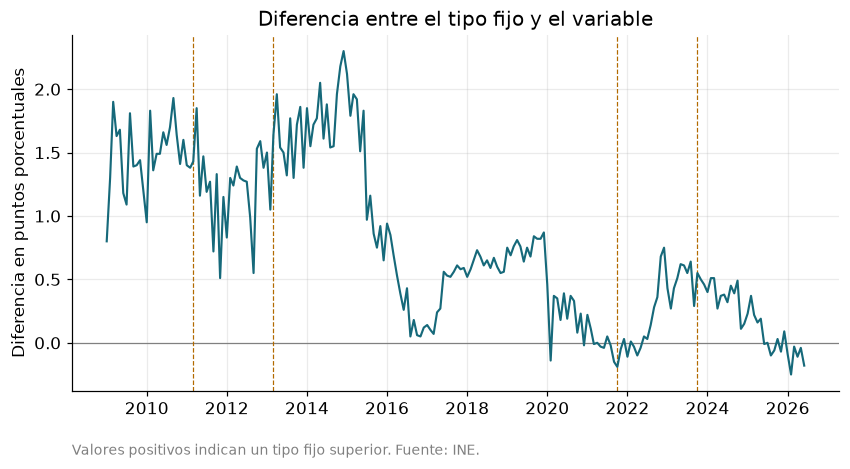

Etapa 1: el tipo fijo superó al variable en 1.47 puntos de media.
Etapa más reciente: la distancia es de 0.19 puntos.


In [14]:
tipos_fijos = hipotecas[(hipotecas["naturaleza_finca"] == "Viviendas") & (hipotecas["tipo_interes"] == "Fijo")][["fecha", "tipo_hipotecario"]].rename(columns={"tipo_hipotecario": "tipo_fijo"})
tipos_variables = hipotecas[(hipotecas["naturaleza_finca"] == "Viviendas") & (hipotecas["tipo_interes"] == "Variable")][["fecha", "tipo_hipotecario"]].rename(columns={"tipo_hipotecario": "tipo_variable"})
diferencia_productos = tipos_fijos.merge(tipos_variables, on="fecha").sort_values("fecha")
diferencia_productos["diferencia"] = diferencia_productos["tipo_fijo"] - diferencia_productos["tipo_variable"]
diferencia_productos["etapa"] = an.assign_stage(diferencia_productos["fecha"], etapas)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axhline(0, color="grey", linewidth=0.8)
for f in fechas_ruptura:
    ax.axvline(f, color=COLOR_ACCENT, linestyle="--", linewidth=0.8)
ax.plot(diferencia_productos["fecha"], diferencia_productos["diferencia"], color=COLOR_MAIN, linewidth=1.4)
ax.set_title("Diferencia entre el tipo fijo y el variable")
ax.set_ylabel("Diferencia en puntos porcentuales")
ax.text(0.0, -0.18, "Valores positivos indican un tipo fijo superior. Fuente: INE.", transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "07_diferencia_fijo_variable.png")
plt.show()

resumen_diferencia = diferencia_productos.groupby("etapa")["diferencia"].mean()
print(f"Etapa 1: el tipo fijo superó al variable en {resumen_diferencia.iloc[0]:.2f} puntos de media.")
print(f"Etapa más reciente: la distancia es de {resumen_diferencia.iloc[-1]:.2f} puntos.")

La brecha entre el tipo fijo y el variable se ha reducido de forma clara
desde la primera etapa: el mercado español pasó de un uso casi exclusivo de
la hipoteca variable a una oferta donde la fija es mucho más competitiva.

## 8. Estabilidad temporal de los patrones

Para que la conclusión sobre estacionalidad no dependa de una fecha de corte
elegida arbitrariamente, repetimos el contraste conjunto de la sección 6 en
ventanas móviles de ocho años.

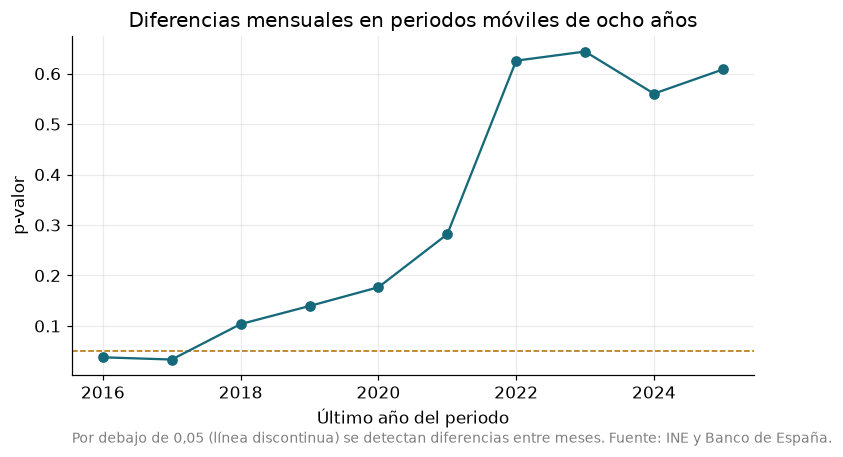

In [15]:
resultados_ventanas = an.rolling_window_test(hipotecas, euribor, window_years=8)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0.05, color=COLOR_ACCENT, linestyle="--", linewidth=1)
ax.plot(resultados_ventanas["fin"], resultados_ventanas["p_valor"], color=COLOR_MAIN, marker="o")
ax.set_title("Diferencias mensuales en periodos móviles de ocho años")
ax.set_xlabel("Último año del periodo")
ax.set_ylabel("p-valor")
ax.text(0.0, -0.2, "Por debajo de 0,05 (línea discontinua) se detectan diferencias entre meses. Fuente: INE y Banco de España.",
        transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "08_estabilidad_ventanas_moviles.png")
plt.show()

In [16]:
significativas = resultados_ventanas[resultados_ventanas["p_valor"] < 0.05]
if len(significativas):
    print(f"Las diferencias aparecen en ventanas antiguas, pero dejan de detectarse tras la ventana terminada en {int(significativas['fin'].max())}.")
else:
    print("Ninguna ventana de ocho años detecta diferencias mensuales.")

Las diferencias aparecen en ventanas antiguas, pero dejan de detectarse tras la ventana terminada en 2017.


El patrón que aparecía al usar todo el histórico no se mantiene en las
ventanas más recientes: la señal de estacionalidad se concentra en el pasado
y se diluye en los últimos años. Combinado con la sección 6 (solo diciembre
sobrevive a la corrección por comparaciones múltiples, y en el sentido de
tipo más *alto*, no más bajo) y la sección 7 (el resultado no es igual en
fijo que en variable), la conclusión es consistente: **no hay un patrón
mensual estable y aprovechable**.

## 9. Forecasting

Comparamos cuatro alternativas para prever el tipo hipotecario medio a 1, 3 y
6 meses: mantener el último valor (*naive*), un modelo ETS, un ARIMA y un
ARIMAX que incorpora el Euríbor. No se fuerza ninguna pauta estacional en los
modelos, porque las secciones 6-8 ya muestran que no es un patrón estable ni
fiable.

Las previsiones se generan con `src/update_forecasts.py`, que guarda los
resultados en `outputs/tables/`. Ese script hace también el backtesting de la
sección 10; no se repite aquí para no recalcular más de una hora de modelos
en cada ejecución del cuaderno. Para regenerarlo:

```bash
python src/update_forecasts.py
```

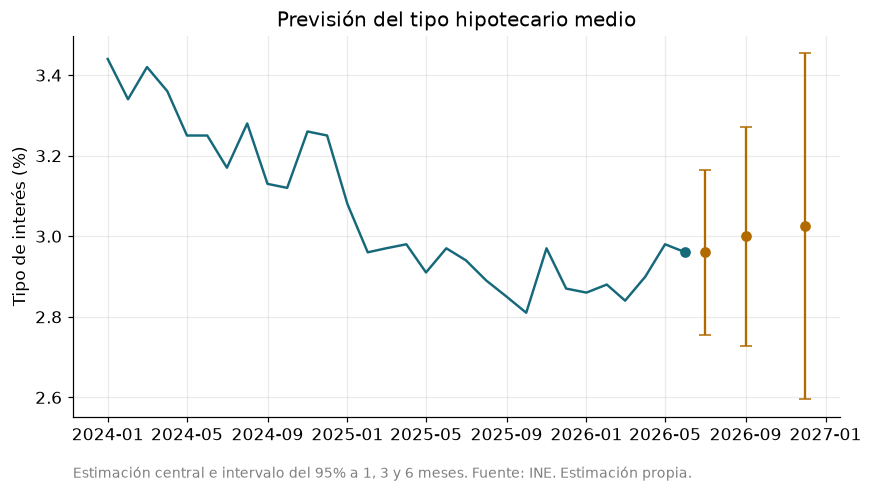

,Horizonte,Fecha,Modelo,Estimación central,Intervalo del 95%
0,1 mes,julio de 2026,Valor reciente,2.96 %,2.75 % - 3.17 %
4,3 meses,septiembre de 2026,ETS sin estacionalidad,3.00 %,2.73 % - 3.27 %
5,6 meses,diciembre de 2026,ETS sin estacionalidad,3.03 %,2.59 % - 3.46 %


In [17]:
forecast_actual = pd.read_csv(TABLES_DIR / "current_forecasts.csv", parse_dates=["origin_date", "target_date"])
evaluacion_forecast = pd.read_csv(TABLES_DIR / "forecast_evaluation.csv")
historial_forecast = pd.read_csv(TABLES_DIR / "forecast_history.csv", parse_dates=["issue_date", "origin_date", "target_date"])
metadata_forecast = json.loads((TABLES_DIR / "forecast_metadata.json").read_text(encoding="utf-8"))

forecast_seleccionado = forecast_actual[forecast_actual["selected"]].copy()
forecast_seleccionado["modelo"] = forecast_seleccionado["model"].map(fc.MODEL_LABELS)
forecast_seleccionado["horizonte"] = forecast_seleccionado["horizon_months"].map({1: "1 mes", 3: "3 meses", 6: "6 meses"})
forecast_seleccionado = forecast_seleccionado.sort_values("horizon_months")

ultimo_observado = viviendas.iloc[-1]
historico_reciente = viviendas.tail(30)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(historico_reciente["fecha"], historico_reciente["tipo_hipotecario"], color=COLOR_MAIN, linewidth=1.6)
ax.scatter([ultimo_observado["fecha"]], [ultimo_observado["tipo_hipotecario"]], color=COLOR_MAIN, zorder=5)
ax.errorbar(
    forecast_seleccionado["target_date"], forecast_seleccionado["forecast"],
    yerr=[forecast_seleccionado["forecast"] - forecast_seleccionado["lower_95"],
          forecast_seleccionado["upper_95"] - forecast_seleccionado["forecast"]],
    fmt="o", color=COLOR_ACCENT, ecolor=COLOR_ACCENT, capsize=4,
)
ax.set_title("Previsión del tipo hipotecario medio")
ax.set_ylabel("Tipo de interés (%)")
ax.text(0.0, -0.16, "Estimación central e intervalo del 95% a 1, 3 y 6 meses. Fuente: INE. Estimación propia.",
        transform=ax.transAxes, fontsize=9, color="grey")
save_fig(fig, "09_prevision_tipo_hipotecario.png")
plt.show()

tabla_forecast = forecast_seleccionado.assign(
    Fecha=forecast_seleccionado["target_date"].apply(dp.fecha_mes_es),
    **{
        "Estimación central": forecast_seleccionado["forecast"].map(lambda v: f"{v:.2f} %"),
        "Intervalo del 95%": forecast_seleccionado.apply(lambda r: f"{r['lower_95']:.2f} % - {r['upper_95']:.2f} %", axis=1),
    },
)[["horizonte", "Fecha", "modelo", "Estimación central", "Intervalo del 95%"]]
tabla_forecast.columns = ["Horizonte", "Fecha", "Modelo", "Estimación central", "Intervalo del 95%"]
tabla_forecast

In [18]:
forecast_6m = forecast_seleccionado.loc[forecast_seleccionado["horizon_months"] == 6].iloc[0]
print(f"Último valor observado: {ultimo_observado['tipo_hipotecario']:.2f} %")
print(f"Estimación central a 6 meses: {forecast_6m['forecast']:.2f} % (intervalo 95%: {forecast_6m['lower_95']:.2f} % - {forecast_6m['upper_95']:.2f} %)")

Último valor observado: 2.96 %
Estimación central a 6 meses: 3.03 % (intervalo 95%: 2.59 % - 3.46 %)


El escenario central es prácticamente estable en los tres horizontes, pero el
intervalo se amplía con el horizonte, como cabe esperar. La previsión
describe el promedio nacional de las nuevas hipotecas, no la oferta que
recibiría una persona concreta.

## 10. Backtesting / evaluación de modelos

La validación repite la previsión desde 60 fechas históricas (orígenes
móviles). En cada una, el modelo solo utiliza datos que habrían estado
disponibles en ese momento — incluido el Euríbor del ARIMAX, que respeta el
desfase real de publicación frente al dato hipotecario del INE (ver
`src/forecasting.py::future_euribor_path`). Se compara el error absoluto
medio (MAE), la raíz del error cuadrático medio (RMSE) y la cobertura de los
intervalos de previsión.

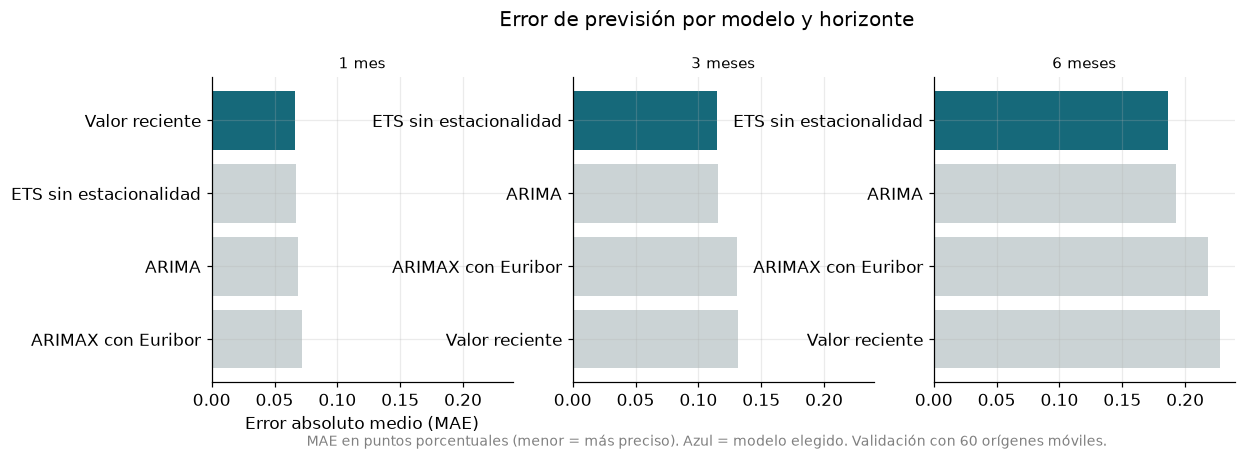

,Horizonte,Modelo,MAE,RMSE,Cobertura 80%,Cobertura 95%,Elegido
0,1 mes,Valor reciente,0.067,0.095,88.3 %,96.7 %,Sí
1,1 mes,ETS sin estacionalidad,0.067,0.096,85.0 %,96.7 %,
2,1 mes,ARIMA,0.068,0.097,83.3 %,96.7 %,
3,1 mes,ARIMAX con Euribor,0.072,0.100,78.3 %,98.3 %,
4,3 meses,ETS sin estacionalidad,0.115,0.169,78.3 %,91.7 %,Sí
5,3 meses,ARIMA,0.115,0.174,78.3 %,91.7 %,
6,3 meses,ARIMAX con Euribor,0.131,0.184,73.3 %,90.0 %,
7,3 meses,Valor reciente,0.132,0.191,85.0 %,93.3 %,
8,6 meses,ETS sin estacionalidad,0.186,0.302,78.3 %,88.3 %,Sí
9,6 meses,ARIMA,0.193,0.320,75.0 %,86.7 %,


In [19]:
evaluacion_grafico = evaluacion_forecast.copy()
evaluacion_grafico["modelo"] = evaluacion_grafico["model"].map(fc.MODEL_LABELS)
evaluacion_grafico["horizonte"] = evaluacion_grafico["horizon_months"].map({1: "1 mes", 3: "3 meses", 6: "6 meses"})

horizonte_orden = ["1 mes", "3 meses", "6 meses"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True)
for ax, horizonte in zip(axes, horizonte_orden):
    sub = evaluacion_grafico[evaluacion_grafico["horizonte"] == horizonte].sort_values("mae")
    colores = [COLOR_MAIN if s else "#CBD3D5" for s in sub["selected"]]
    ax.barh(sub["modelo"], sub["mae"], color=colores)
    ax.set_title(horizonte, fontsize=10)
    ax.invert_yaxis()
axes[0].set_xlabel("Error absoluto medio (MAE)")
fig.suptitle("Error de previsión por modelo y horizonte", y=1.05)
fig.text(0.5, -0.05, "MAE en puntos porcentuales (menor = más preciso). Azul = modelo elegido. Validación con 60 orígenes móviles.",
         ha="center", fontsize=9, color="grey")
save_fig(fig, "10_error_prevision_por_modelo.png")
plt.show()

tabla_evaluacion = evaluacion_grafico.sort_values(["horizon_months", "mae"]).assign(
    MAE=lambda d: d["mae"].map(lambda v: f"{v:.3f}"),
    RMSE=lambda d: d["rmse"].map(lambda v: f"{v:.3f}"),
    **{
        "Cobertura 80%": lambda d: d["coverage_80"].map(lambda v: f"{100*v:.1f} %"),
        "Cobertura 95%": lambda d: d["coverage_95"].map(lambda v: f"{100*v:.1f} %"),
    }
)
tabla_evaluacion["Elegido"] = np.where(tabla_evaluacion["selected"], "Sí", "")
tabla_evaluacion = tabla_evaluacion[["horizonte", "modelo", "MAE", "RMSE", "Cobertura 80%", "Cobertura 95%", "Elegido"]]
tabla_evaluacion.columns = ["Horizonte", "Modelo", "MAE", "RMSE", "Cobertura 80%", "Cobertura 95%", "Elegido"]
tabla_evaluacion

In [20]:
modelos_elegidos = forecast_seleccionado["modelo"].unique()
if len(modelos_elegidos) == 1:
    print(f"El modelo {modelos_elegidos[0]} obtiene el menor MAE en los tres horizontes.")
else:
    print("El modelo con menor MAE cambia según el horizonte.")

print(f"Los intervalos del 95% cubren entre {100*evaluacion_forecast['coverage_95'].min():.1f}% y {100*evaluacion_forecast['coverage_95'].max():.1f}% de los valores observados en el backtest.")

El modelo con menor MAE cambia según el horizonte.
Los intervalos del 95% cubren entre 83.3% y 98.3% de los valores observados en el backtest.


El ARIMAX permite comprobar si añadir el Euríbor mejora la previsión, pero no
gana en los horizontes evaluados: el modelo elegido es el que realmente
reduce el error fuera de muestra, aunque sea el más sencillo.

### Seguimiento de acierto

Cada ejecución del pipeline (`src/update_forecasts.py`) añade la previsión
vigente al histórico sin sobrescribir las anteriores. Cuando el INE publica
el dato real correspondiente, se calcula el error de la previsión ya emitida
— nunca se sustituye lo que se había pronosticado.

In [21]:
tabla_historial = historial_forecast.sort_values(["origin_date", "horizon_months"], ascending=[False, True]).copy()
tabla_historial["Modelo"] = tabla_historial["model"].map(fc.MODEL_LABELS)
tabla_historial["Horizonte"] = tabla_historial["horizon_months"].map({1: "1 mes", 3: "3 meses", 6: "6 meses"})
tabla_historial["Previsión"] = tabla_historial["forecast"].map(lambda v: f"{v:.2f} %")
tabla_historial["Observado"] = tabla_historial["observed"].map(lambda v: "Pendiente" if pd.isna(v) else f"{v:.2f} %")
tabla_historial["Error absoluto"] = tabla_historial["abs_error"].map(lambda v: "-" if pd.isna(v) else f"{v:.3f}")
tabla_historial["Emisión"] = tabla_historial["issue_date"].dt.date.astype(str)
tabla_historial["Origen"] = tabla_historial["origin_date"].apply(dp.fecha_mes_es)
tabla_historial["Objetivo"] = tabla_historial["target_date"].apply(dp.fecha_mes_es)
tabla_historial[["Emisión", "Origen", "Horizonte", "Objetivo", "Modelo", "Previsión", "Observado", "Error absoluto"]]

,Emisión,Origen,Horizonte,Objetivo,Modelo,Previsión,Observado,Error absoluto
3,2026-09-10,junio de 2026,1 mes,julio de 2026,Valor reciente,2.96 %,Pendiente,-
4,2026-09-10,junio de 2026,3 meses,septiembre de 2026,ETS sin estacionalidad,3.00 %,Pendiente,-
5,2026-09-10,junio de 2026,6 meses,diciembre de 2026,ETS sin estacionalidad,3.03 %,Pendiente,-
0,2026-09-10,mayo de 2026,1 mes,junio de 2026,ETS sin estacionalidad,2.95 %,2.96 %,0.005
1,2026-09-10,mayo de 2026,3 meses,agosto de 2026,ETS sin estacionalidad,2.98 %,Pendiente,-
2,2026-09-10,mayo de 2026,6 meses,noviembre de 2026,ETS sin estacionalidad,3.01 %,Pendiente,-


## 11. Resultados principales

- **No se identifica un mes sistemáticamente más barato** para contratar una
  hipoteca. La comparación simple (sección 6) ya deja el intervalo de
  septiembre muy cerca de cero; tras controlar por el Euríbor y corregir por
  comparar doce meses a la vez, **ningún mes ofrece un tipo fiablemente más
  bajo** — la única diferencia que sobrevive (diciembre) va en el sentido
  contrario, hacia un tipo más alto.
- Ese resultado **no es estable en el tiempo**: las ventanas móviles de ocho
  años muestran diferencias en el pasado que dejan de detectarse en los
  periodos recientes (sección 8).
- **Tampoco es igual entre hipotecas fijas y variables** (sección 7): el tipo
  fijo sí muestra diferencias mensuales, el variable no.
- El mercado atraviesa **etapas con relaciones muy distintas** frente al
  Euríbor (secciones 4-5): la correlación y la sensibilidad mensual cambian
  de signo y magnitud entre etapas: un cambio del Euríbor no se traslada de
  forma automática y constante al tipo medio en el mismo mes.
- La brecha entre el tipo fijo y el variable **se ha reducido con claridad**
  desde la primera etapa analizada (sección 7).

Las dos conclusiones siguientes dependen de los datos y modelos más
recientes, así que se generan automáticamente a partir de los resultados ya
calculados en las secciones 9 y 10 (no son texto fijo):

In [22]:
from IPython.display import Markdown, display

ganadores = evaluacion_grafico.loc[evaluacion_grafico["selected"], ["horizonte", "modelo"]]
resumen_ganadores = ", ".join(f"{r.horizonte}: {r.modelo}" for r in ganadores.itertuples())
modelos_unicos = ganadores["modelo"].unique()
if len(modelos_unicos) == 1:
    texto_ganador = f"el modelo **{modelos_unicos[0]}** obtiene el menor error (MAE) en los tres horizontes evaluados (1, 3 y 6 meses)"
else:
    texto_ganador = f"el modelo con menor error (MAE) cambia según el horizonte — {resumen_ganadores}"

arimax_gana_alguno = "arimax_euribor" in evaluacion_grafico.loc[evaluacion_grafico["selected"], "model"].values
texto_arimax = (
    "En ningún horizonte el modelo mejora con el Euríbor como variable exógena (ARIMAX)."
    if not arimax_gana_alguno
    else "En al menos un horizonte, incorporar el Euríbor como variable exógena (ARIMAX) sí reduce el error."
)

f6 = forecast_seleccionado.loc[forecast_seleccionado["horizon_months"] == 6].iloc[0]
texto_forecast = (
    f"La previsión vigente (sección 9) sitúa el tipo medio en torno al "
    f"{f6['forecast']:.2f} % a seis meses (intervalo 95%: {f6['lower_95']:.2f} % - {f6['upper_95']:.2f} %), "
    f"prácticamente en línea con el último dato observado ({ultimo_observado['tipo_hipotecario']:.2f} %)."
)

display(Markdown(
    f"- En la validación fuera de muestra (sección 10), {texto_ganador}. {texto_arimax}\n"
    f"- {texto_forecast}"
))

- En la validación fuera de muestra (sección 10), el modelo con menor error (MAE) cambia según el horizonte — 1 mes: Valor reciente, 3 meses: ETS sin estacionalidad, 6 meses: ETS sin estacionalidad. En ningún horizonte el modelo mejora con el Euríbor como variable exógena (ARIMAX).
- La previsión vigente (sección 9) sitúa el tipo medio en torno al 3.03 % a seis meses (intervalo 95%: 2.59 % - 3.46 %), prácticamente en línea con el último dato observado (2.96 %).

## 12. Limitaciones

- Los datos son **agregados y mensuales**: no reflejan la dispersión de
  ofertas entre bancos ni las condiciones de una hipoteca concreta (importe,
  plazo, perfil del solicitante).
- El tipo hipotecario medio del INE mezcla operaciones a tipo fijo y
  variable en proporciones que han cambiado mucho con los años; parte de lo
  que parece "cambio de tendencia" es también cambio de composición.
- El mercado ha atravesado **cambios estructurales** relevantes (tipos
  negativos, subida muy rápida en 2022-2023); los modelos de previsión no
  incorporan explícitamente esos cambios de régimen, solo se adaptan a ellos
  con los datos más recientes.
- Los modelos de previsión (naive, ETS, ARIMA, ARIMAX) son intencionadamente
  sencillos y comparables entre sí; no se ha buscado exprimir el mínimo error
  posible con modelos más complejos.
- La incertidumbre de cualquier previsión aumenta con el horizonte: los
  intervalos a 6 meses son bastante más anchos que a 1 mes, y deben
  interpretarse como un rango razonable, no como un límite garantizado.

## 13. Conclusiones

No existe evidencia de un mes sistemáticamente más barato para contratar una
hipoteca en España. Las diferencias mensuales que aparecen al mirar todo el
histórico no son estables en los años recientes ni se repiten igual entre
hipotecas fijas y variables, así que esperar a un mes concreto no ofrece una
ventaja fiable.

El Euríbor ayuda a explicar el contexto general del mercado — el tipo
hipotecario medio atraviesa etapas claramente ligadas a su evolución — pero
su cambio mes a mes no se traslada de forma constante al tipo hipotecario, y
añadirlo como variable exógena tampoco mejora la previsión frente al mejor
modelo puramente temporal en la validación realizada.

Con los datos disponibles, la previsión central mantiene el tipo medio
estable en los próximos 1, 3 y 6 meses, con una incertidumbre que crece con
el horizonte. Esta conclusión no es definitiva: se revisa automáticamente
cada mes según llegan nuevos datos oficiales (ver `.github/workflows/update-data.yml`).